In [66]:
from calendar import weekday, month
import datetime as dt
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels as sm
import sklearn
import math
from statsmodels.formula.api import ols
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from datetime import date, timedelta
import holidays
import statistics
from statsmodels.nonparametric.smoothers_lowess import lowess

In [111]:

def getdf():
    df = pd.read_csv("Dailydf.csv",parse_dates=["Date"],index_col="Unnamed: 0")
    return df

df = getdf()
def plotShit(frame):
    #This function plots forecast statistics, Takes argument frame returned by getFrame()
    fig, ax = plt.subplots(3,2,figsize=(20,12),constrained_layout=True)
    sns.histplot(frame["Errors"],ax=ax[0,0])
    sns.lineplot(frame["Errors"],ax=ax[0,1])
    sns.lineplot(frame["Observed"],ax=ax[1,0])
    sns.lineplot(frame["Predicted"],ax=ax[1,0])
    sns.lineplot(frame["SD"],ax=ax[1,1])

    plot_acf(frame["Errors"],ax=ax[2,0])
    plot_pacf(frame["Errors"],ax=ax[2,1])


    return

def getMovingSD(values,window):
    # Utility for getting rolling estimate of  standard deviation for parameter array
    length = len(values)
    sd = [None]*length

    for i in range(0, len(values)-window-window):
        sd[i+window] = statistics.stdev(values[i:i+window+window])

    first = sd[window]
    last = sd[len(values)-window-1]
    for i in range(0,window):
        sd[i] = first
        sd[length-i-1] = last
    return sd


def getFrame(model, obs, w = 45,idx=df["Date"]):
    #Produces frame for model, pass observations as list (df["consumption"].values)
    # w is the window lenght for rolling sd, idx is frame index (defaults to dates of original data)
    errors = obs-model.predict()
    sds = getMovingSD(errors,w)
    frame = pd.DataFrame({"Predicted":model.predict(), "SD": sds,  "Observed":obs, "Errors":errors }, index=idx)
    return frame

def isWorkday(date):
    hol = holidays.FI()
    if date.weekday() in (5,6):
        return False
    elif date in hol:
        return False
    else:
        return True

def isSummer(month):
    if month in [6,7,8,9]:
        return 20
    elif month in [1,2]:
        return 30
    elif month in [3,11]:
        return 40
    elif month in [4,10]:
        return 50
    else:
        return month


In [68]:




# Not used yet, can be used to forecast specific dates.
def fitModel(date,data, plotshit=True):

    df1 = data[data["Date"]<=date]



    df1 = df1[df1["l2"]!=0]

    m = ols(formula="log_consumption ~ C(month) + C(workday) + trend + l1_log", data=df1)
    r = m.fit()

    if plotshit:
        err = r.predict()-df1["log_consumption"]
        plotShit(err)
        ##
        plt.figure()
        sns.lineplot(df1["log_consumption"],color="r")
        sns.lineplot(r.predict())

    tplus1 = date+ timedelta(days=1)
    tplus2 = date+ timedelta(days=2)
    trend0 = max(df1["trend"])
    xt1 =  {"month" : tplus1.month,
           "workday" : isWorkday(tplus1),
           "trend" : trend0+1,
           "l1_log" : df1.iloc[-1,:]["l1_log"]}

    yt1 = r.predict(xt1)
    xt2 = {"month" : tplus2.month,
           "workday" : isWorkday(tplus2),
           "trend" : trend0+2,
           "l1_log" : yt1}
    yt2 = r.predict(xt2)

    return r, yt2




<Axes: xlabel='month'>

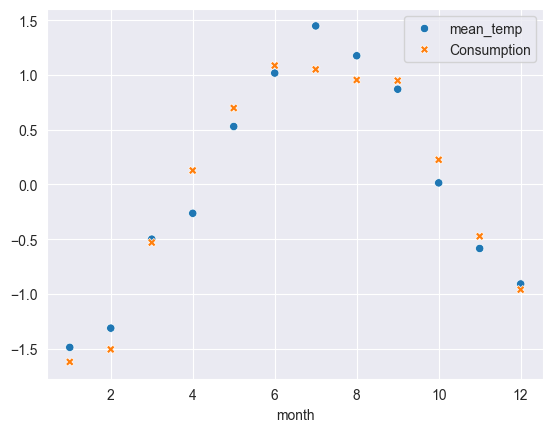

In [103]:
df = pd.read_csv("Dailydf.csv",parse_dates=["Date"],index_col="Unnamed: 0")
d = df.groupby("month").aggregate({"mean_temp":"mean", "Consumption":"mean"})
d["Consumption"] = -(d["Consumption"]-np.mean(d["Consumption"]))/statistics.stdev(d["Consumption"])
d["mean_temp"] = (d["mean_temp"]-np.mean(d["mean_temp"]))/statistics.stdev(d["mean_temp"])
sns.scatterplot(d)

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        log_consumption   R-squared:                       0.851
Model:                            OLS   Adj. R-squared:                  0.849
Method:                 Least Squares   F-statistic:                     443.5
Date:                Thu, 02 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:09:47   Log-Likelihood:                 1226.9
No. Observations:                 945   AIC:                            -2428.
Df Residuals:                     932   BIC:                            -2365.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         12.5357      0.008   1525.026      0.000      12.520      12.552
C(month)[T.2]     -0.0174      0.010     -1.712      0.087      -0.037       0.003
C(month)[T.3]     -0.1582      0.010    -15.523      0.000      -0.178      -0.138
C(month)[T.4]     -0.2493      0.011    -22.390      0.000      -0.271      -0.227
C(month)[T.5]     -0.3550      0.011    -32.231      0.000      -0.377      -0.333
C(month)[T.6]     -0.4327      0.011    -38.935      0.000      -0.455      -0.411
C(month)[T.7]     -0.4269      0.011    -38.801      0.000      -0.449      -0.405
C(month)[T.8]     -0.3950      0.010    -39.748      0.000      -0.414      -0.375
C(month)[T.9]     -0.3967      0.010    -39.715      0.000      -0.416      -0.377
C(month)[T.10]    -0.2668      0.010    -26.980      0.000      -0.286      -0.247
C(month)[T.11]    -0.1563      0.010    -15.702      0.000      -0.176      -0.137
C(month)[T.12]    -0.0855      0.010     -8.394      0.000      -0.105      -0.066
trend           9.073e-05   8.12e-06     11.168      0.000    7.48e-05       0.000
==============================================================================
Omnibus:                        9.661   Durbin-Watson:                   0.448
Prob(Omnibus):                  0.008   Jarque-Bera (JB):               14.175
Skew:                          -0.039   Prob(JB):                     0.000836
Kurtosis:                       3.595   Cond. No.                     6.46e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.46e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

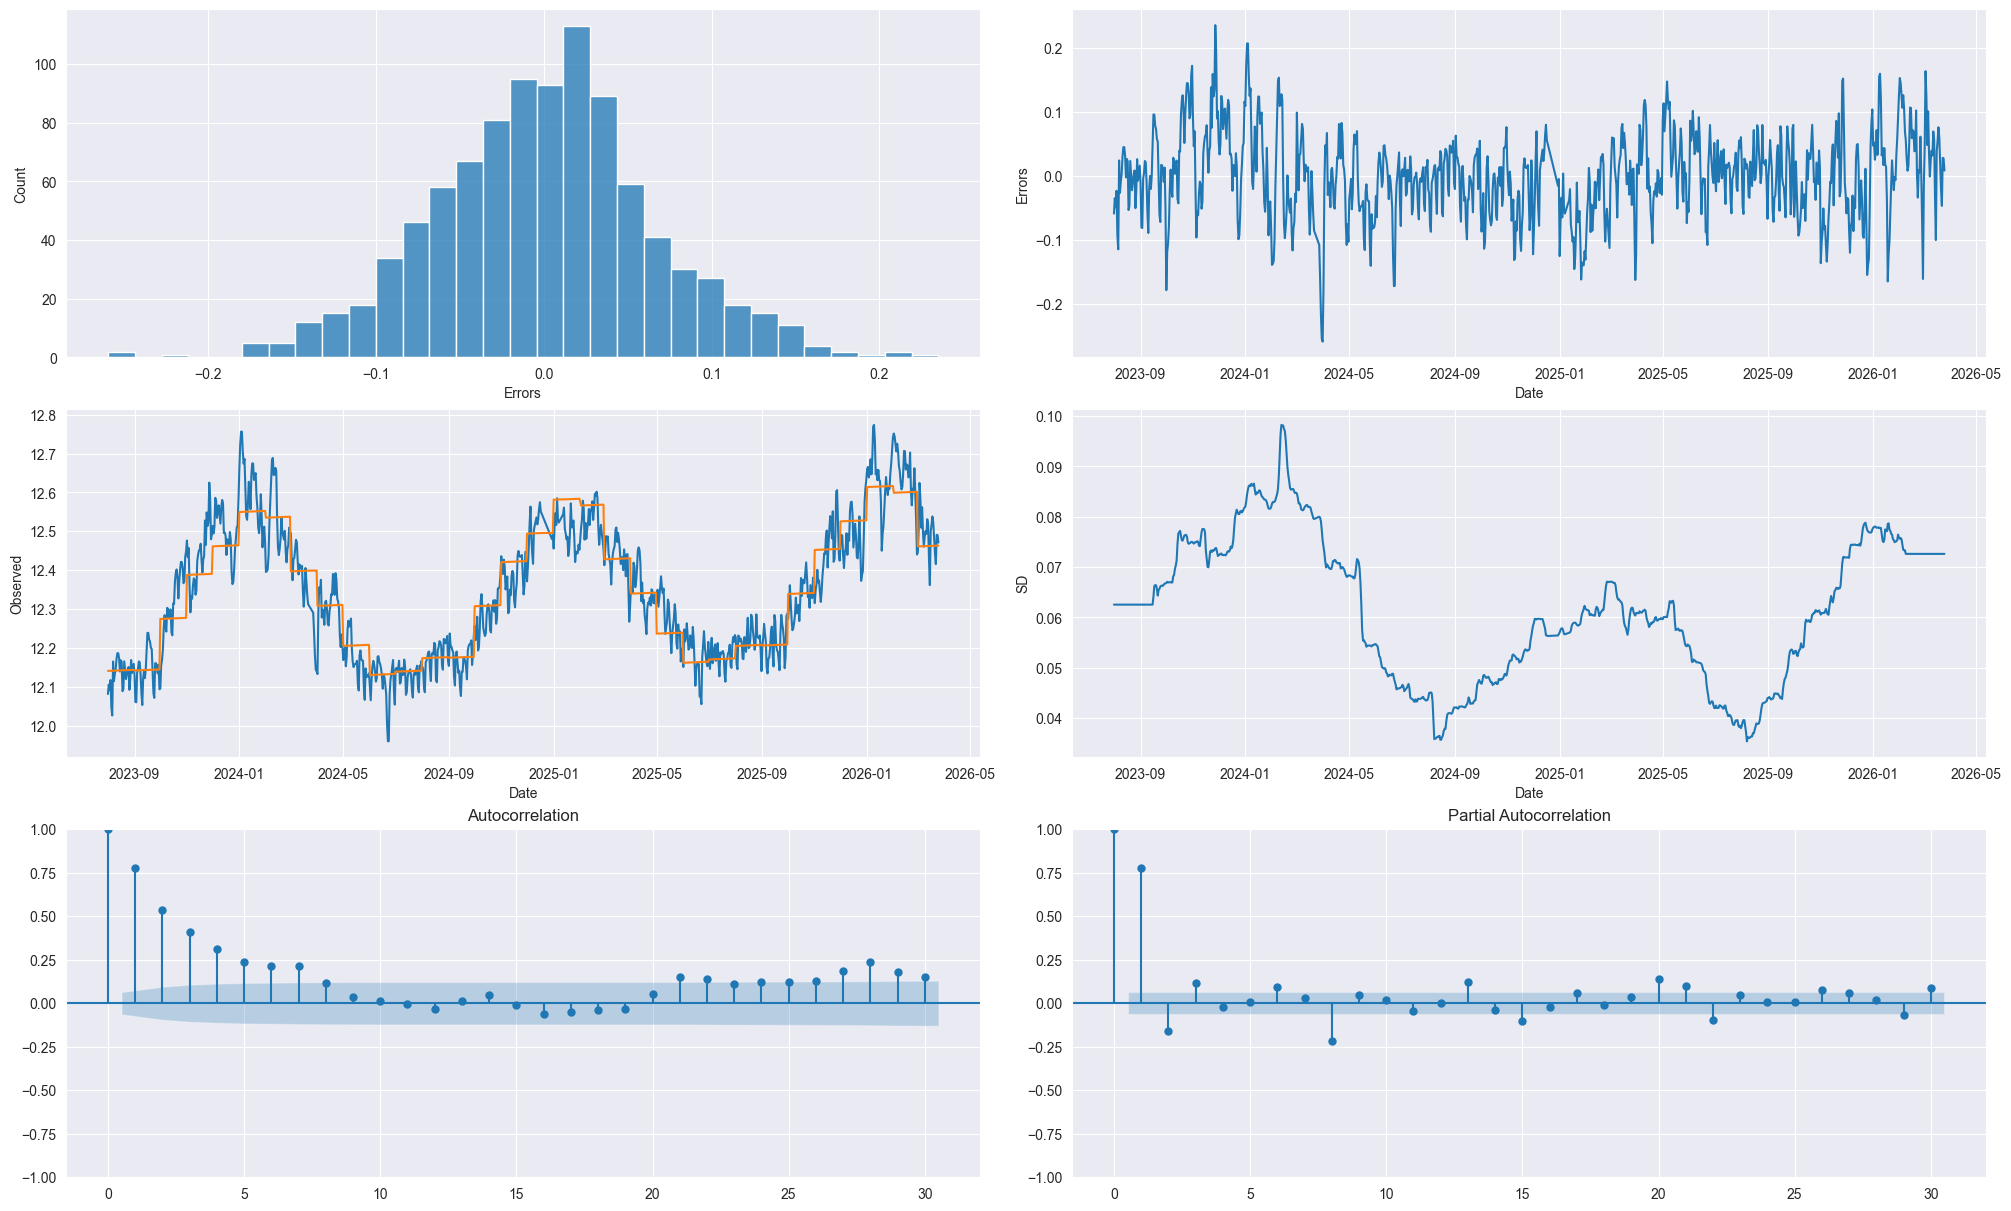

In [70]:
#WEEK 1: Month + trend
df = pd.read_csv("Dailydf.csv",parse_dates=["Date"],index_col="Unnamed: 0")
formula = "log_consumption ~ C(month) + trend "
model1  = ols(formula, data=df).fit()

frame1 = getFrame(model1,df["log_consumption"].values)
plotShit(frame1)
model1.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        log_consumption   R-squared:                       0.866
Model:                            OLS   Adj. R-squared:                  0.864
Method:                 Least Squares   F-statistic:                     462.5
Date:                Thu, 02 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:09:49   Log-Likelihood:                 1276.8
No. Observations:                 945   AIC:                            -2526.
Df Residuals:                     931   BIC:                            -2458.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          12.5050      0.008   1494.805      0.000      12.489      12.521
C(month)[T.2]      -0.0195      0.010     -2.018      0.044      -0.038      -0.001
C(month)[T.3]      -0.1586      0.010    -16.398      0.000      -0.178      -0.140
C(month)[T.4]      -0.2497      0.011    -23.629      0.000      -0.270      -0.229
C(month)[T.5]      -0.3544      0.010    -33.903      0.000      -0.375      -0.334
C(month)[T.6]      -0.4316      0.011    -40.918      0.000      -0.452      -0.411
C(month)[T.7]      -0.4300      0.010    -41.162      0.000      -0.451      -0.410
C(month)[T.8]      -0.3966      0.009    -42.044      0.000      -0.415      -0.378
C(month)[T.9]      -0.3984      0.009    -42.015      0.000      -0.417      -0.380
C(month)[T.10]     -0.2694      0.009    -28.691      0.000      -0.288      -0.251
C(month)[T.11]     -0.1575      0.009    -16.666      0.000      -0.176      -0.139
C(month)[T.12]     -0.0837      0.010     -8.655      0.000      -0.103      -0.065
workday[T.True]     0.0455      0.004     10.185      0.000       0.037       0.054
trend            9.097e-05   7.71e-06     11.798      0.000    7.58e-05       0.000
==============================================================================
Omnibus:                       13.377   Durbin-Watson:                   0.369
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               18.764
Skew:                           0.139   Prob(JB):                     8.42e-05
Kurtosis:                       3.632   Cond. No.                     6.46e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.46e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

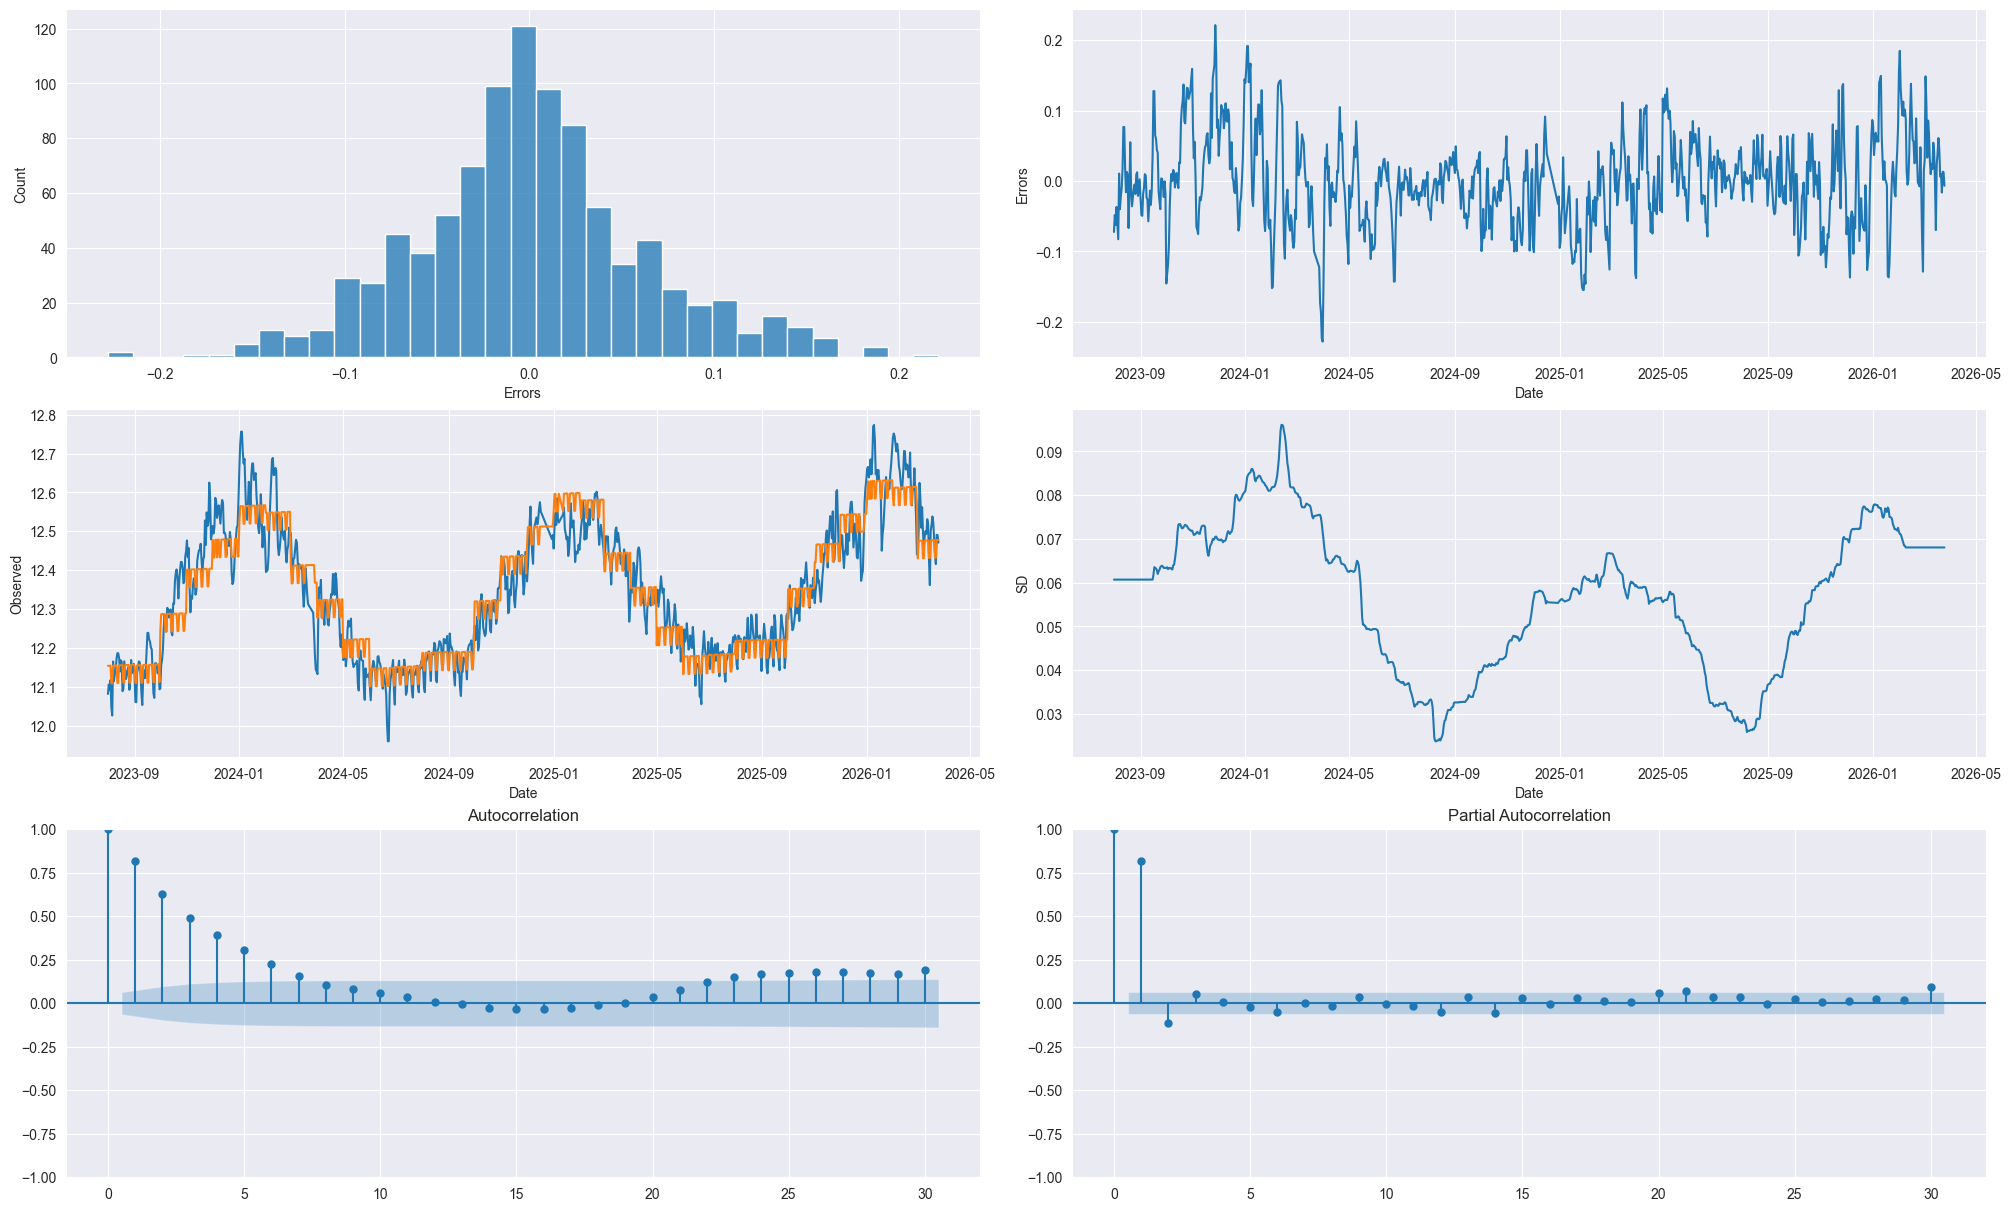

In [71]:
#WEEK 2: Month + workday + trend
df = pd.read_csv("Dailydf.csv",parse_dates=["Date"],index_col="Unnamed: 0")
formula = "log_consumption ~ C(month) + workday+ trend"
model2  = ols(formula, data=df).fit()

frame2 = getFrame(model2,df["log_consumption"].values)
plotShit(frame2)
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        log_consumption   R-squared:                       0.924
Model:                            OLS   Adj. R-squared:                  0.922
Method:                 Least Squares   F-statistic:                     801.2
Date:                Thu, 02 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:09:51   Log-Likelihood:                 1540.5
No. Observations:                 943   AIC:                            -3051.
Df Residuals:                     928   BIC:                            -2978.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           4.4503      0.304     14.662      0.000       3.855       5.046
C(month)[T.2]      -0.0123      0.007     -1.690      0.091      -0.027       0.002
C(month)[T.3]      -0.0663      0.008     -8.209      0.000      -0.082      -0.050
C(month)[T.4]      -0.0876      0.010     -8.715      0.000      -0.107      -0.068
C(month)[T.5]      -0.1313      0.012    -11.393      0.000      -0.154      -0.109
C(month)[T.6]      -0.1552      0.013    -11.844      0.000      -0.181      -0.130
C(month)[T.7]      -0.1545      0.013    -11.857      0.000      -0.180      -0.129
C(month)[T.8]      -0.1423      0.012    -11.948      0.000      -0.166      -0.119
C(month)[T.9]      -0.1430      0.012    -11.924      0.000      -0.167      -0.119
C(month)[T.10]     -0.0913      0.010     -9.354      0.000      -0.110      -0.072
C(month)[T.11]     -0.0554      0.008     -6.835      0.000      -0.071      -0.039
C(month)[T.12]     -0.0238      0.008     -3.117      0.002      -0.039      -0.009
workday[T.True]     0.0574      0.003     16.892      0.000       0.051       0.064
trend            3.323e-05   6.21e-06      5.348      0.000     2.1e-05    4.54e-05
l2_log              0.6419      0.024     26.543      0.000       0.594       0.689
==============================================================================
Omnibus:                        9.450   Durbin-Watson:                   0.988
Prob(Omnibus):                  0.009   Jarque-Bera (JB):               12.656
Skew:                           0.097   Prob(JB):                      0.00179
Kurtosis:                       3.533   Cond. No.                     1.08e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.08e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

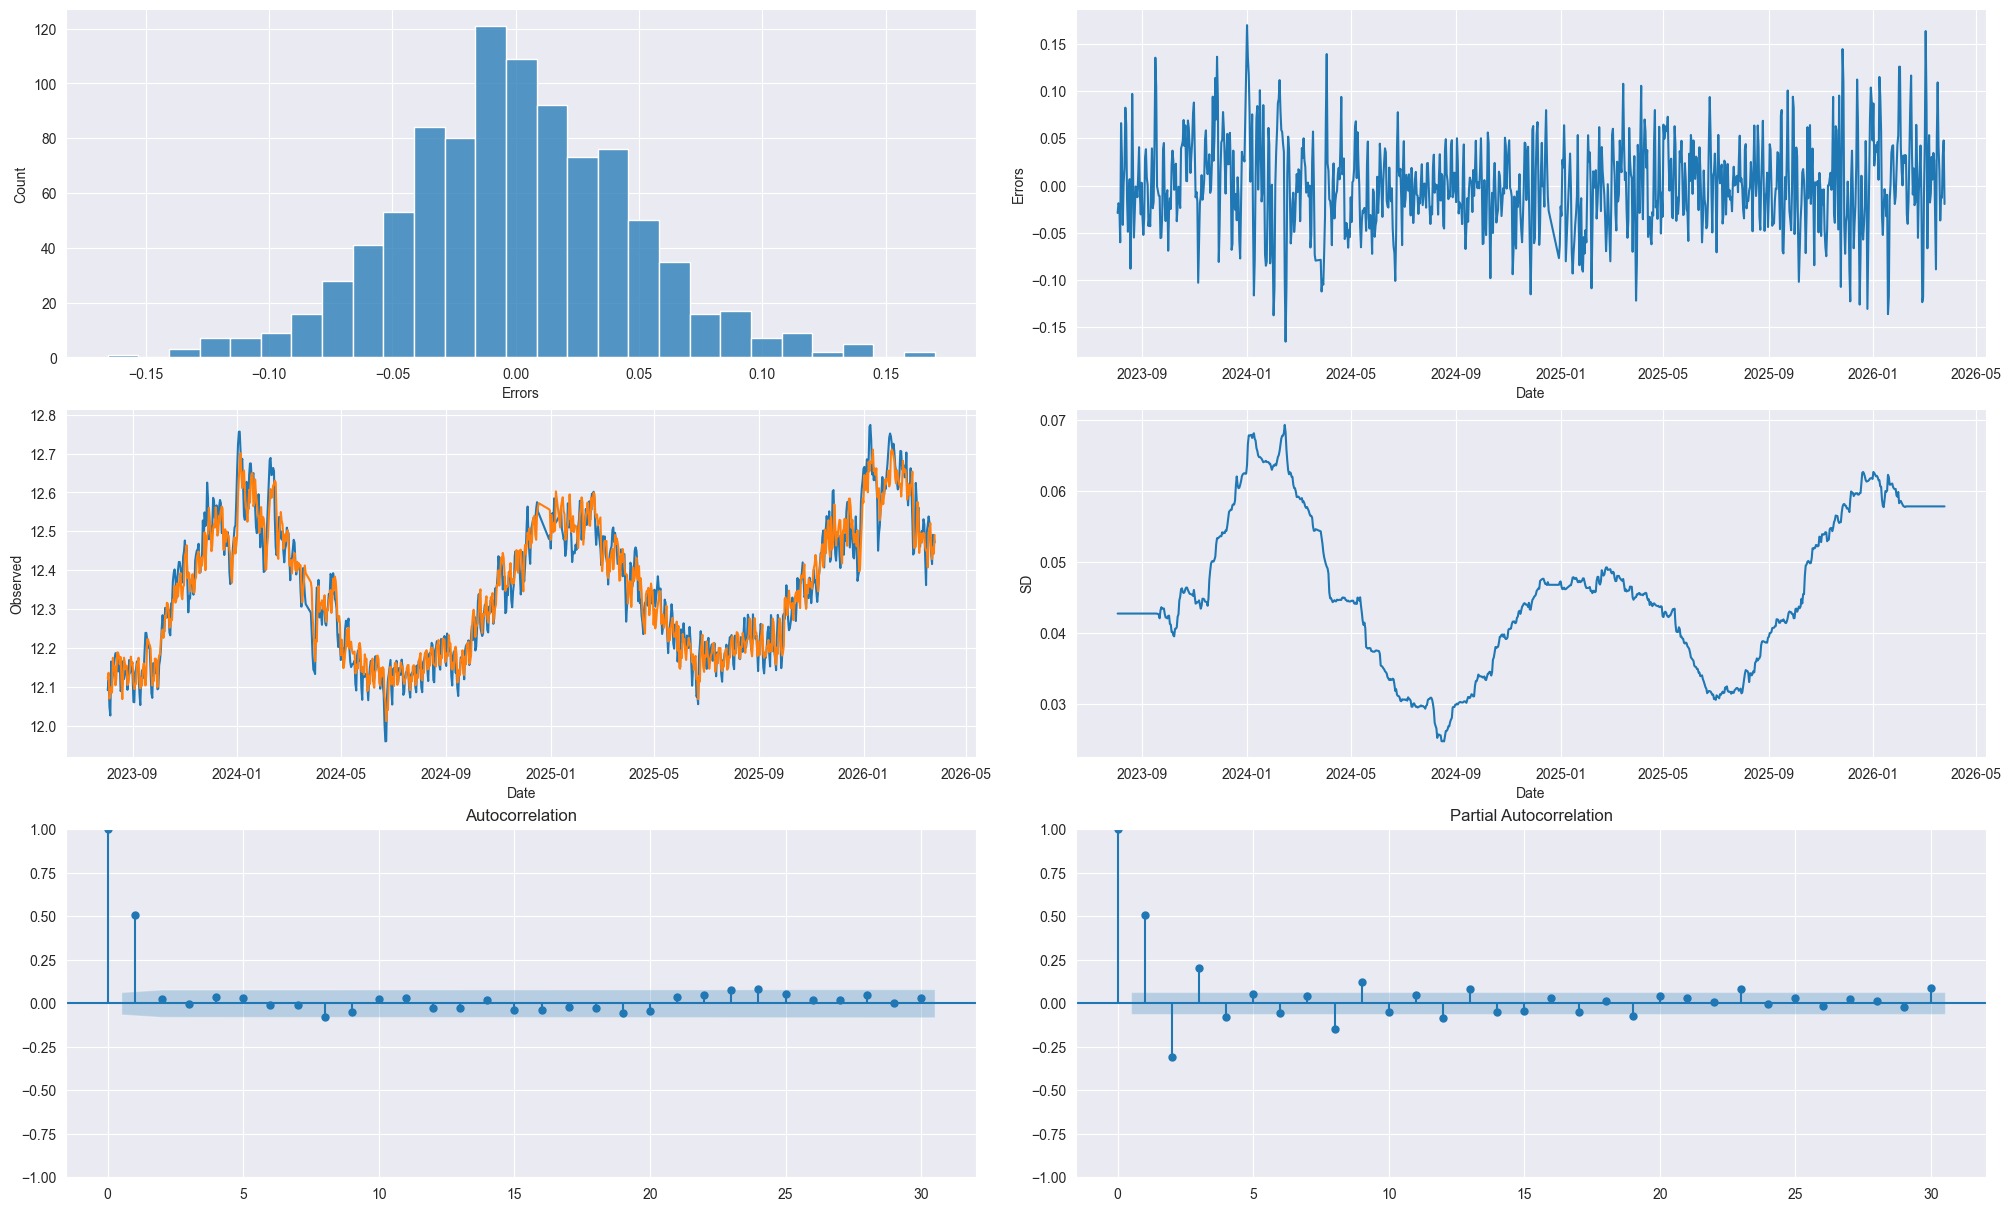

In [72]:
#WEEK 3: AR2
df = pd.read_csv("Dailydf.csv",parse_dates=["Date"],index_col="Unnamed: 0")[2:] #get rid of the first rows with 0 lag values
formula = "log_consumption ~ C(month) + workday+ trend + l2_log"
model3 = ols(formula, data=df).fit()

frame3 = getFrame(model3,df["log_consumption"].values,idx=df["Date"])
plotShit(frame3)
model3.summary()


Still autocorrelated errors, starts to approximate the demand quite well though. Standard deviation appears somewhat seasonal.
As demonstrated below, autocorrelated errors can be made to diminish with AR1 but we don't have that information when predicting so we need to figure out some way to deal with that. Maybe some kind of temperature gradient? Kalman filter is apparently useful at weather forecasting.


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        log_consumption   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                  0.957
Method:                 Least Squares   F-statistic:                     1484.
Date:                Thu, 02 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:09:53   Log-Likelihood:                 1814.2
No. Observations:                 943   AIC:                            -3598.
Df Residuals:                     928   BIC:                            -3526.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.5469      0.223     11.405      0.000       2.109       2.985
C(month)[T.2]      -0.0077      0.005     -1.412      0.158      -0.018       0.003
C(month)[T.3]      -0.0371      0.006     -6.085      0.000      -0.049      -0.025
C(month)[T.4]      -0.0502      0.007     -6.738      0.000      -0.065      -0.036
C(month)[T.5]      -0.0746      0.009     -8.665      0.000      -0.092      -0.058
C(month)[T.6]      -0.0882      0.010     -9.060      0.000      -0.107      -0.069
C(month)[T.7]      -0.0884      0.010     -9.146      0.000      -0.107      -0.069
C(month)[T.8]      -0.0820      0.009     -9.292      0.000      -0.099      -0.065
C(month)[T.9]      -0.0813      0.009     -9.132      0.000      -0.099      -0.064
C(month)[T.10]     -0.0518      0.007     -7.190      0.000      -0.066      -0.038
C(month)[T.11]     -0.0316      0.006     -5.236      0.000      -0.043      -0.020
C(month)[T.12]     -0.0119      0.006     -2.100      0.036      -0.023      -0.001
workday[T.True]     0.0401      0.003     15.914      0.000       0.035       0.045
trend            1.902e-05   4.64e-06      4.095      0.000     9.9e-06    2.81e-05
l1_log              0.7946      0.018     44.601      0.000       0.760       0.830
==============================================================================
Omnibus:                       12.383   Durbin-Watson:                   1.634
Prob(Omnibus):                  0.002   Jarque-Bera (JB):               14.132
Skew:                           0.204   Prob(JB):                     0.000854
Kurtosis:                       3.440   Cond. No.                     1.06e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.06e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

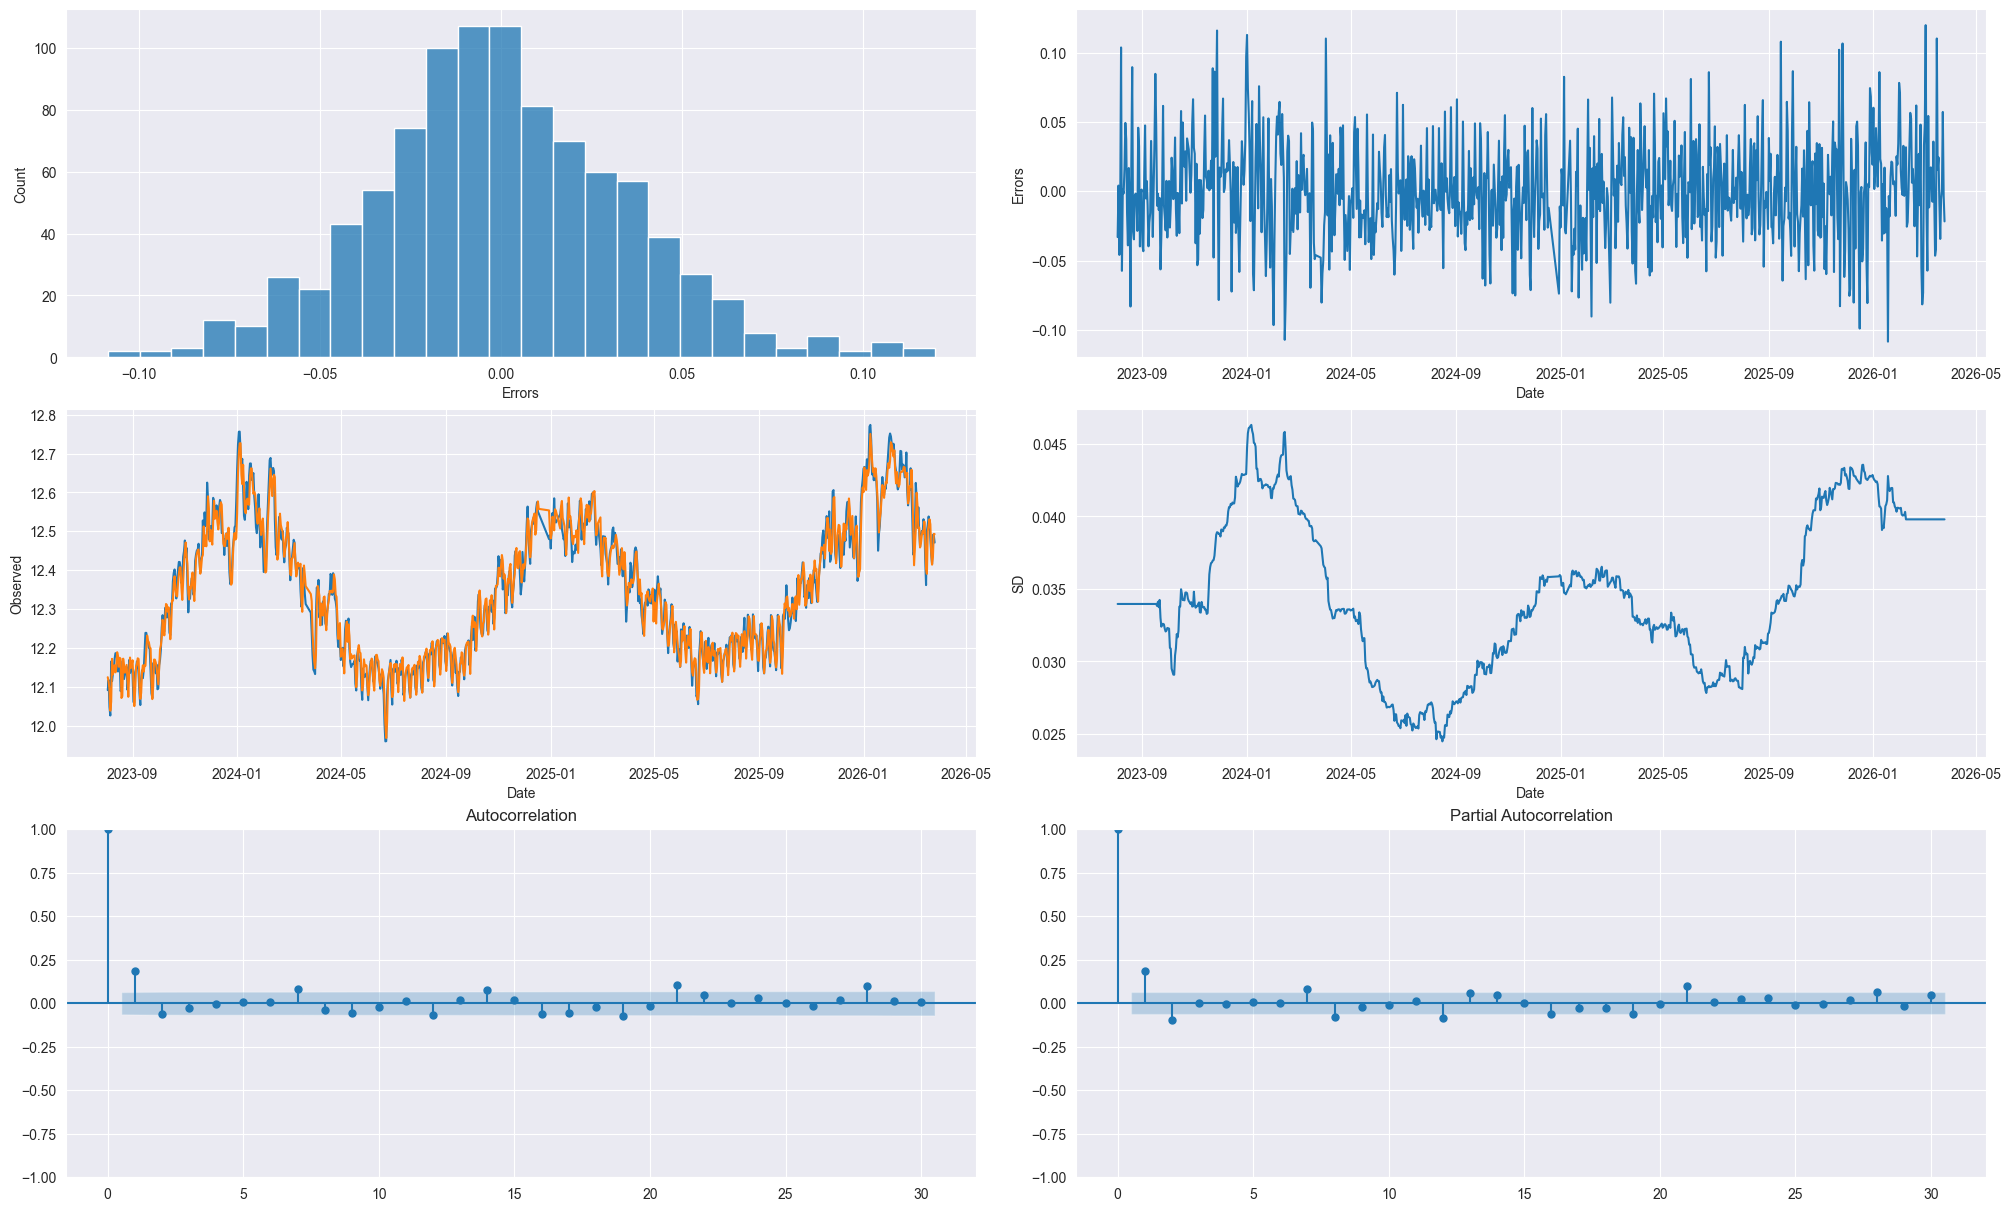

In [73]:
df = pd.read_csv("Dailydf.csv",parse_dates=["Date"],index_col="Unnamed: 0")[2:] #get rid of the first rows with 0 lag values
formula = "log_consumption ~ C(month) + workday + trend + l1_log"
model_temp = ols(formula, data=df).fit()

frame_temp = getFrame(model_temp,df["log_consumption"].values,idx=df["Date"])
plotShit(frame_temp)
model_temp.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        log_consumption   R-squared:                       0.921
Model:                            OLS   Adj. R-squared:                  0.920
Method:                 Least Squares   F-statistic:                     1552.
Date:                Thu, 02 Apr 2026   Prob (F-statistic):               0.00
Time:                        13:19:56   Log-Likelihood:                 1523.4
No. Observations:                 943   AIC:                            -3031.
Df Residuals:                     935   BIC:                            -2992.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            3.7584      0.279     13.476      0.000       3.211       4.306
workday[T.True]      0.0582      0.003     16.917      0.000       0.051       0.065
C(month_s)[T.12]     0.0965      0.010      9.633      0.000       0.077       0.116
C(month_s)[T.20]    -0.0140      0.007     -2.026      0.043      -0.027      -0.000
C(month_s)[T.30]     0.1115      0.011     10.420      0.000       0.090       0.132
C(month_s)[T.40]     0.0632      0.008      7.437      0.000       0.047       0.080
C(month_s)[T.50]     0.0370      0.007      4.938      0.000       0.022       0.052
l2_log               0.6889      0.023     30.249      0.000       0.644       0.734
==============================================================================
Omnibus:                       12.297   Durbin-Watson:                   1.005
Prob(Omnibus):                  0.002   Jarque-Bera (JB):               18.281
Skew:                           0.095   Prob(JB):                     0.000107
Kurtosis:                       3.655   Cond. No.                     2.21e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.21e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

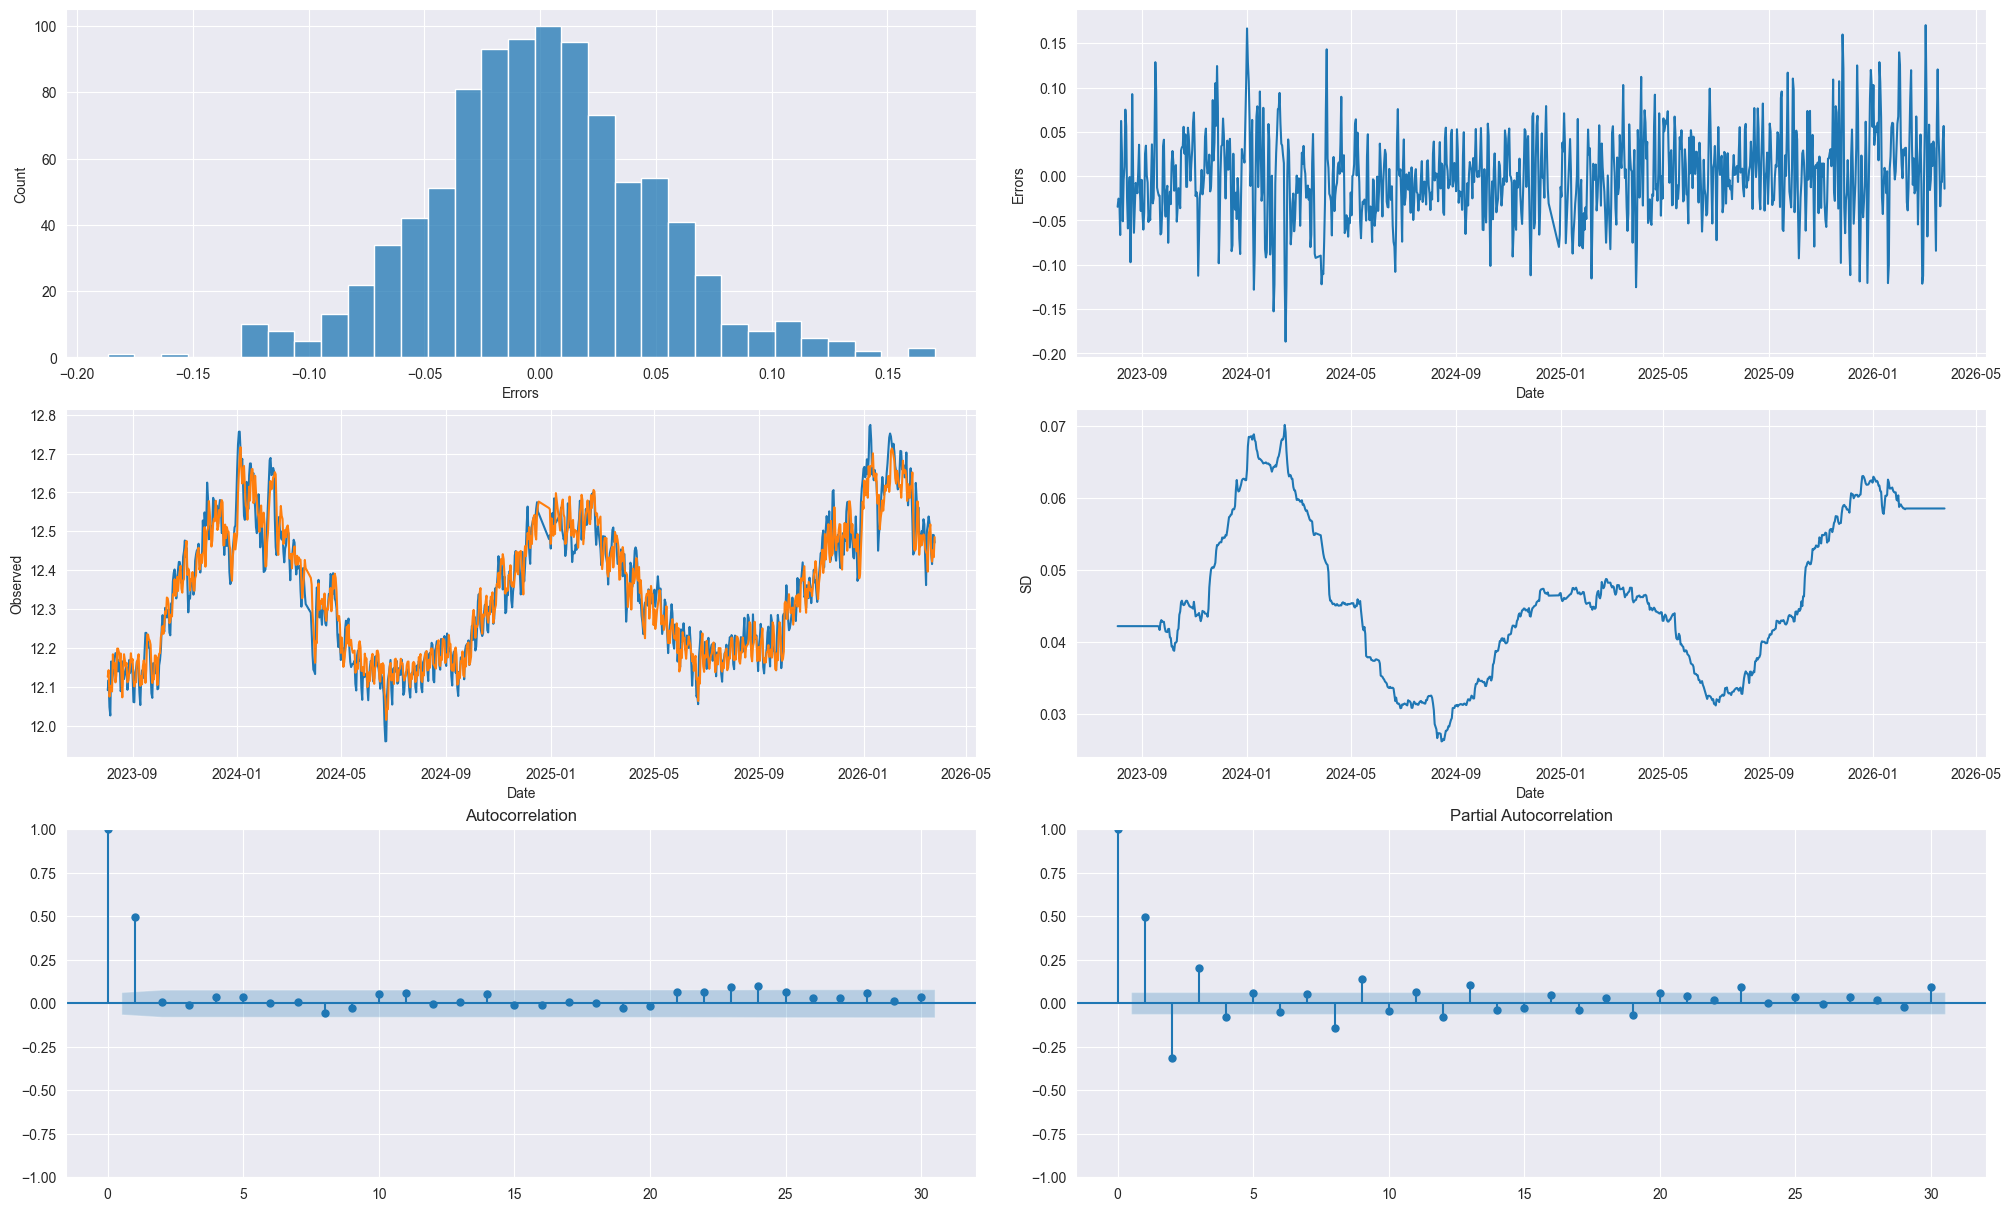

In [112]:
    # WEEK 4:
df = pd.read_csv("Dailydf.csv",parse_dates=["Date"],index_col="Unnamed: 0")[2:] #get rid of the first rows with 0 lag values
df["month_s"] = df["month"].apply(isSummer)


formula = "log_consumption ~ workday+  l2_log+C(month_s)"
model4 = ols(formula, data=df).fit()

frame4 = getFrame(model4,df["log_consumption"].values,idx=df["Date"])
plotShit(frame4)
model4.summary()

In [75]:
# WEEK 6:

In [76]:
#scraps
df1 = pd.read_csv("Dailydf.csv",parse_dates=["Date"])

df_spring = df1[df1["Date"]>=dt.datetime(2026,1,1)].set_index("Date").loc[:,["log_consumption","trend"]]
df_spring["predicted"] = pd.Series()

date = dt.datetime(2026,1,1)

while date<dt.datetime(2026,3,18):
    r,y = fitModel(date-dt.timedelta(days=2),df1, False)
    df_spring.loc[date, "predicted"] = y[0]
    date+=dt.timedelta(days=1)


